In [1]:
import numpy as np
import time
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn

np.random.seed(42)


## Kalman 分解與相關性工具

定義高低兩個 component 相關性摘要、Kalman filter，以及利用 Kalman filter 將觀測序列拆成線性與非線性部分的函式。

In [2]:
def component_correlation_summary(linear_part, nonlinear_part):
    linear_part = np.asarray(linear_part, dtype=float)
    nonlinear_part = np.asarray(nonlinear_part, dtype=float)

    if linear_part.shape != nonlinear_part.shape:
        raise ValueError("linear_part and nonlinear_part must have the same shape.")

    if linear_part.size < 2:
        return {
            "pearson_corr": np.nan,
            "abs_pearson_corr": np.nan,
            "corr_sq": np.nan,
            "covariance": np.nan,
        }

    pearson_corr = float(np.corrcoef(linear_part, nonlinear_part)[0, 1])
    covariance = float(np.cov(linear_part, nonlinear_part, ddof=1)[0, 1])
    return {
        "pearson_corr": pearson_corr,
        "abs_pearson_corr": abs(pearson_corr),
        "corr_sq": pearson_corr ** 2,
        "covariance": covariance,
    }


def kalman_filter(observations, process_variance=0.5, measurement_variance=10.0, initial_error=1.0):
    initial_estimate = float(observations[0])
    estimated_state = initial_estimate
    estimate_error = float(initial_error)
    estimated_states = []

    for measurement in observations:
        predicted_state = estimated_state
        predicted_error = estimate_error + process_variance

        kalman_gain = predicted_error / (predicted_error + measurement_variance)
        estimated_state = predicted_state + kalman_gain * (measurement - predicted_state)
        estimate_error = (1.0 - kalman_gain) * predicted_error
        estimated_states.append(estimated_state)

    return np.array(estimated_states, dtype=float)


def decompose_with_simple_kf(series, process_variance=0.5, measurement_variance=10.0):
    estimated_low = kalman_filter(
        series,
        process_variance=process_variance,
        measurement_variance=measurement_variance,
        initial_error=1.0,
    )
    estimated_high = np.array(series, dtype=float) - estimated_low
    return estimated_low, estimated_high


## Joint DistPred 模型與訓練工具

這一段定義 joint window 建立方式、MLP 模型、loss function，以及 joint DistPred 的訓練與遞迴預測流程。

In [3]:
def create_joint_windows(low_series, high_series, window_size):
    features = []
    targets = []
    for idx in range(window_size, len(low_series)):
        low_window = np.asarray(low_series[idx - window_size:idx], dtype=float)
        high_window = np.asarray(high_series[idx - window_size:idx], dtype=float)
        joint_window = np.column_stack([low_window, high_window]).reshape(-1)
        features.append(joint_window)
        targets.append([float(low_series[idx]), float(high_series[idx])])
    return np.asarray(features, dtype=float), np.asarray(targets, dtype=float)


class JointDistPredMLP(nn.Module):
    def __init__(self, input_dim, ensemble_size):
        super().__init__()
        self.ensemble_size = ensemble_size
        self.net = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, ensemble_size * 2),
        )

    def forward(self, x):
        out = self.net(x)
        return out.view(-1, self.ensemble_size, 2)


def distpred_eq13_loss(pred_ensemble, y_true):
    if pred_ensemble.ndim != 2:
        raise ValueError("pred_ensemble must have shape (batch_size, ensemble_size).")

    ensemble_size = pred_ensemble.shape[1]
    if ensemble_size < 2:
        raise ValueError("Eq.13 requires ensemble_size >= 2.")

    y_true = y_true.unsqueeze(1)
    calibration_term = torch.abs(pred_ensemble - y_true).mean(dim=1)
    sorted_pred, _ = torch.sort(pred_ensemble, dim=1)
    order = torch.arange(ensemble_size, device=pred_ensemble.device, dtype=pred_ensemble.dtype)
    l_moment_term = sorted_pred.mean(dim=1) - (
        2.0 / (ensemble_size * (ensemble_size - 1))
    ) * (sorted_pred * order.unsqueeze(0)).sum(dim=1)
    return (calibration_term + l_moment_term).mean()


def joint_distpred_loss(pred_ensemble, y_true):
    low_loss = distpred_eq13_loss(pred_ensemble[:, :, 0], y_true[:, 0])
    high_loss = distpred_eq13_loss(pred_ensemble[:, :, 1], y_true[:, 1])
    return 0.5 * (low_loss + high_loss)


def picp_from_interval(interval_lower, interval_upper, y_true):
    interval_lower = np.asarray(interval_lower, dtype=float)
    interval_upper = np.asarray(interval_upper, dtype=float)
    y_true = np.asarray(y_true, dtype=float)
    covered = (y_true >= interval_lower) & (y_true <= interval_upper)
    return float(np.mean(covered))


def fit_joint_distpred_bundle(low_train, high_train, window_size, ensemble_size=50, epochs=250, learning_rate=1e-3):
    x_train, y_train = create_joint_windows(low_train, high_train, window_size)
    if len(x_train) == 0:
        raise ValueError("Not enough samples for joint DistPred windows. Increase training size or reduce window_size.")

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()
    x_train_scaled = x_scaler.fit_transform(x_train)
    y_train_scaled = y_scaler.fit_transform(y_train).astype(np.float32)

    x_tensor = torch.tensor(x_train_scaled, dtype=torch.float32)
    y_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)

    model = JointDistPredMLP(input_dim=x_train.shape[1], ensemble_size=ensemble_size)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    model.train()
    for _ in range(epochs):
        optimizer.zero_grad()
        pred_ensemble = model(x_tensor)
        loss = joint_distpred_loss(pred_ensemble, y_tensor)
        loss.backward()
        optimizer.step()

    low_q = np.quantile(low_train, [0.01, 0.99])
    high_q = np.quantile(high_train, [0.01, 0.99])
    low_iqr = np.subtract(*np.quantile(low_train, [0.75, 0.25]))
    high_iqr = np.subtract(*np.quantile(high_train, [0.75, 0.25]))
    low_margin = max(0.5 * low_iqr, 0.25)
    high_margin = max(0.5 * high_iqr, 0.25)
    clip_bounds = (
        (float(low_q[0] - low_margin), float(low_q[1] + low_margin)),
        (float(high_q[0] - high_margin), float(high_q[1] + high_margin)),
    )

    return {
        "model": model.eval(),
        "x_scaler": x_scaler,
        "y_scaler": y_scaler,
        "clip_bounds": clip_bounds,
        "window_size": window_size,
        "ensemble_size": ensemble_size,
    }


def one_step_joint_distpred_forecast(bundle, low_history, high_history, future_low_reference, future_high_reference, window_size):
    combined_low = np.concatenate([np.asarray(low_history[-window_size:], dtype=float), np.asarray(future_low_reference, dtype=float)])
    combined_high = np.concatenate([np.asarray(high_history[-window_size:], dtype=float), np.asarray(future_high_reference, dtype=float)])
    testX, _ = create_joint_windows(combined_low, combined_high, window_size)
    if len(testX) == 0:
        raise ValueError("No valid joint test windows were created for one-step rolling forecast.")

    features_scaled = bundle["x_scaler"].transform(testX)
    with torch.no_grad():
        pred_scaled = bundle["model"](torch.tensor(features_scaled, dtype=torch.float32)).cpu().numpy()

    horizon = pred_scaled.shape[0]
    ensemble_size = bundle["ensemble_size"]
    pred = bundle["y_scaler"].inverse_transform(pred_scaled.reshape(-1, 2)).reshape(horizon, ensemble_size, 2)
    low_samples = np.clip(pred[:, :, 0].T, bundle["clip_bounds"][0][0], bundle["clip_bounds"][0][1])
    high_samples = np.clip(pred[:, :, 1].T, bundle["clip_bounds"][1][0], bundle["clip_bounds"][1][1])
    return low_samples, high_samples


def fit_joint_distpred_component(
    low_train,
    high_train,
    future_low_reference,
    future_high_reference,
    horizon,
    window_size,
    ensemble_size=50,
):
    bundle = fit_joint_distpred_bundle(
        low_train,
        high_train,
        window_size,
        ensemble_size=ensemble_size,
    )
    low_samples, high_samples = one_step_joint_distpred_forecast(
        bundle,
        low_train,
        high_train,
        future_low_reference,
        future_high_reference,
        window_size,
    )
    low_forecast = np.mean(low_samples, axis=0)
    high_forecast = np.mean(high_samples, axis=0)
    return low_forecast, high_forecast, low_samples, high_samples, bundle


def hybrid_point_forecast(train_series, horizon, future_low_reference=None, future_high_reference=None, window_size=15, ensemble_size=50):
    if future_low_reference is None or future_high_reference is None:
        raise ValueError("paper26-style one-step rolling joint forecast requires future_low_reference and future_high_reference.")

    estimated_low, estimated_high = decompose_with_simple_kf(train_series)
    low_forecast, high_forecast, low_samples, high_samples, bundle = fit_joint_distpred_component(
        estimated_low,
        estimated_high,
        future_low_reference,
        future_high_reference,
        horizon,
        window_size=window_size,
        ensemble_size=ensemble_size,
    )
    final_samples = low_samples + high_samples
    final_forecast = low_forecast + high_forecast

    return {
        "estimated_low": estimated_low,
        "estimated_high": estimated_high,
        "low_forecast": low_forecast,
        "high_forecast": high_forecast,
        "low_samples": low_samples,
        "high_samples": high_samples,
        "joint_bundle": bundle,
        "final_samples": final_samples,
        "final_forecast": final_forecast,
        "window_size": window_size,
    }


def timed_hybrid_point_forecast(train_series, horizon, future_low_reference=None, future_high_reference=None, window_size=15, ensemble_size=50):
    if future_low_reference is None or future_high_reference is None:
        raise ValueError("paper26-style one-step rolling joint forecast requires future_low_reference and future_high_reference.")

    timing = {
        "kf_decomposition": 0.0,
        "joint_distpred_fit_forecast": 0.0,
    }

    kf_start = time.perf_counter()
    estimated_low, estimated_high = decompose_with_simple_kf(train_series)
    timing["kf_decomposition"] += time.perf_counter() - kf_start

    joint_start = time.perf_counter()
    low_forecast, high_forecast, low_samples, high_samples, bundle = fit_joint_distpred_component(
        estimated_low,
        estimated_high,
        future_low_reference,
        future_high_reference,
        horizon,
        window_size=window_size,
        ensemble_size=ensemble_size,
    )
    timing["joint_distpred_fit_forecast"] += time.perf_counter() - joint_start

    final_samples = low_samples + high_samples
    final_forecast = low_forecast + high_forecast

    return {
        "estimated_low": estimated_low,
        "estimated_high": estimated_high,
        "low_forecast": low_forecast,
        "high_forecast": high_forecast,
        "low_samples": low_samples,
        "high_samples": high_samples,
        "joint_bundle": bundle,
        "final_samples": final_samples,
        "final_forecast": final_forecast,
        "window_size": window_size,
    }, timing


## 繪圖工具

這一段提供互動圖與 component 相關性圖的繪製函式，用來觀察線性與非線性部分之間的關係。

In [4]:
def save_interaction_plot(bundle, low_history, high_history, output_path, grid_points=41):
    window_size = bundle["window_size"]
    ensemble_size = bundle["ensemble_size"]
    base_low = np.asarray(low_history[-window_size:], dtype=float)
    base_high = np.asarray(high_history[-window_size:], dtype=float)

    low_min, low_max = bundle["clip_bounds"][0]
    high_min, high_max = bundle["clip_bounds"][1]
    low_grid = np.linspace(low_min, low_max, grid_points)
    high_grid = np.linspace(high_min, high_max, grid_points)

    mean_surface = np.zeros((grid_points, grid_points), dtype=float)
    width_surface = np.zeros((grid_points, grid_points), dtype=float)

    for i, low_val in enumerate(low_grid):
        for j, high_val in enumerate(high_grid):
            low_window = base_low.copy()
            high_window = base_high.copy()
            low_window[-1] = low_val
            high_window[-1] = high_val

            features = np.column_stack([low_window, high_window]).reshape(1, -1)
            features = np.repeat(features, ensemble_size, axis=0)
            features_scaled = bundle["x_scaler"].transform(features)
            with torch.no_grad():
                pred_scaled = bundle["model"](torch.tensor(features_scaled, dtype=torch.float32)).cpu().numpy()

            diag_scaled = pred_scaled[np.arange(ensemble_size), np.arange(ensemble_size), :]
            diag_pred = bundle["y_scaler"].inverse_transform(diag_scaled)
            next_low = np.clip(diag_pred[:, 0], bundle["clip_bounds"][0][0], bundle["clip_bounds"][0][1])
            next_high = np.clip(diag_pred[:, 1], bundle["clip_bounds"][1][0], bundle["clip_bounds"][1][1])
            final_samples = next_low + next_high

            mean_surface[j, i] = np.mean(final_samples)
            width_surface[j, i] = np.quantile(final_samples, 0.975) - np.quantile(final_samples, 0.025)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    mean_im = axes[0].imshow(
        mean_surface,
        origin="lower",
        aspect="auto",
        extent=[low_grid[0], low_grid[-1], high_grid[0], high_grid[-1]],
        cmap="viridis",
    )
    axes[0].set_title("Final Mean vs Last (L,H)")
    axes[0].set_xlabel("Last L")
    axes[0].set_ylabel("Last H")
    fig.colorbar(mean_im, ax=axes[0], shrink=0.85)

    width_im = axes[1].imshow(
        width_surface,
        origin="lower",
        aspect="auto",
        extent=[low_grid[0], low_grid[-1], high_grid[0], high_grid[-1]],
        cmap="magma",
    )
    axes[1].set_title("Final 95% Width vs Last (L,H)")
    axes[1].set_xlabel("Last L")
    axes[1].set_ylabel("Last H")
    fig.colorbar(width_im, ax=axes[1], shrink=0.85)

    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def save_component_correlation_plot(true_low, true_high, estimated_low, estimated_high, output_path):
    fig, axes = plt.subplots(2, 2, figsize=(11, 9))

    true_corr = component_correlation_summary(true_low, true_high)
    estimated_corr = component_correlation_summary(estimated_low, estimated_high)

    axes[0, 0].plot(true_low, label="True linear", linewidth=1.5)
    axes[0, 0].plot(true_high, label="True nonlinear", linewidth=1.2)
    axes[0, 0].set_title(f"Generated components (corr={true_corr['pearson_corr']:.3f})")
    axes[0, 0].legend()

    axes[0, 1].scatter(true_low, true_high, s=12, alpha=0.7)
    axes[0, 1].set_title("Generated linear vs nonlinear")
    axes[0, 1].set_xlabel("True linear")
    axes[0, 1].set_ylabel("True nonlinear")

    axes[1, 0].plot(estimated_low, label="KF linear", linewidth=1.5)
    axes[1, 0].plot(estimated_high, label="KF nonlinear", linewidth=1.2)
    axes[1, 0].set_title(f"KF components (corr={estimated_corr['pearson_corr']:.3f})")
    axes[1, 0].legend()

    axes[1, 1].scatter(estimated_low, estimated_high, s=12, alpha=0.7, color="tab:orange")
    axes[1, 1].set_title("KF linear vs KF nonlinear")
    axes[1, 1].set_xlabel("KF linear")
    axes[1, 1].set_ylabel("KF nonlinear")

    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


## 模擬資料生成與單次實驗函式

這一段定義文獻 giordano 模擬資料生成方式，並封裝單次實驗流程，包含資料生成、KF 分解、joint DistPred 預測與評估指標計算。

In [5]:
def simulate_m1_m3_additive_data(n_steps, noise_std=0.15):
    low_true = np.zeros(n_steps, dtype=float)
    high_true = np.zeros(n_steps, dtype=float)

    low_true[0] = np.random.normal(0, 1.0)
    high_true[0] = np.random.normal(0, 0.5)
    high_true[1] = np.random.normal(0, 0.5)

    for idx in range(1, n_steps):
        shared_error = np.random.normal(0, 1.0)
        low_true[idx] = 0.6 * low_true[idx - 1] + shared_error

        if idx < 2:
            continue

        coeff_1 = 0.5 + 0.9 * np.exp(-(high_true[idx - 1] ** 2))
        coeff_2 = -0.8 - 1.8 * np.exp(-(high_true[idx - 1] ** 2))
        high_true[idx] = (
            coeff_1 * high_true[idx - 1]
            + coeff_2 * high_true[idx - 2]
            + shared_error
        )

    noise = np.random.normal(0, noise_std, size=n_steps)
    measurements = low_true + high_true + noise
    return low_true, high_true, measurements


def run_single_experiment(train_size=300, horizon=1, window_size=15, ensemble_size=50):
    timing_info = {
        "data_generation": 0.0,
        "point_forecast_fit": 0.0,
        "kf_decomposition": 0.0,
        "joint_distpred_fit_forecast": 0.0,
    }

    n_steps = train_size + horizon

    data_start = time.perf_counter()
    low_true, high_true, measurements = simulate_m1_m3_additive_data(n_steps)
    timing_info["data_generation"] += time.perf_counter() - data_start
    true_component_corr = component_correlation_summary(low_true, high_true)
    estimated_low_full, estimated_high_full = decompose_with_simple_kf(measurements)
    kf_component_corr = component_correlation_summary(estimated_low_full, estimated_high_full)
    reference_low_test = estimated_low_full[train_size:]
    reference_high_test = estimated_high_full[train_size:]

    point_start = time.perf_counter()
    full_train_bundle, point_timing = timed_hybrid_point_forecast(
        measurements[:train_size],
        horizon,
        future_low_reference=reference_low_test,
        future_high_reference=reference_high_test,
        window_size=window_size,
        ensemble_size=ensemble_size,
    )
    timing_info["point_forecast_fit"] += time.perf_counter() - point_start
    timing_info["kf_decomposition"] += point_timing["kf_decomposition"]
    timing_info["joint_distpred_fit_forecast"] += point_timing["joint_distpred_fit_forecast"]

    low_forecast = full_train_bundle["low_forecast"]
    high_forecast = full_train_bundle["high_forecast"]
    final_forecast = full_train_bundle["final_forecast"]
    low_samples = full_train_bundle["low_samples"]
    high_samples = full_train_bundle["high_samples"]
    final_samples = full_train_bundle["final_samples"]

    low_interval_lower = np.quantile(low_samples, 0.025, axis=0)
    low_interval_upper = np.quantile(low_samples, 0.975, axis=0)
    high_interval_lower = np.quantile(high_samples, 0.025, axis=0)
    high_interval_upper = np.quantile(high_samples, 0.975, axis=0)
    interval_lower = np.quantile(final_samples, 0.025, axis=0)
    interval_upper = np.quantile(final_samples, 0.975, axis=0)

    measurements_test = measurements[train_size:]
    true_low_test = low_true[train_size:]
    true_high_test = high_true[train_size:]
    true_clean_test = true_low_test + true_high_test

    low_mse = np.mean((low_forecast - reference_low_test) ** 2)
    high_mse = np.mean((high_forecast - reference_high_test) ** 2)
    final_noisy_mse = np.mean((final_forecast - measurements_test) ** 2)
    final_noisy_rmse = float(np.sqrt(final_noisy_mse))
    test_std = float(np.std(measurements_test, ddof=1))
    normalized_rmse = final_noisy_rmse / max(test_std, 1e-8)
    final_median_forecast = np.median(final_samples, axis=0)
    sample_path_mse = np.mean((final_samples - measurements_test.reshape(1, -1)) ** 2, axis=1)
    best_path_idx = int(np.argmin(sample_path_mse))
    best_path_forecast = final_samples[best_path_idx]
    low_component_coverage = picp_from_interval(low_interval_lower, low_interval_upper, reference_low_test) * 100
    high_component_coverage = picp_from_interval(high_interval_lower, high_interval_upper, reference_high_test) * 100
    noisy_in_interval = (measurements_test >= interval_lower) & (measurements_test <= interval_upper)
    noisy_coverage = np.mean(noisy_in_interval) * 100
    mean_interval_width = np.mean(interval_upper - interval_lower)
    low_sample_width = np.mean(low_interval_upper - low_interval_lower)
    high_sample_width = np.mean(high_interval_upper - high_interval_lower)
    final_sample_width = np.mean(interval_upper - interval_lower)

    return {
        "low_mse": low_mse,
        "high_mse": high_mse,
        "final_noisy_mse": final_noisy_mse,
        "final_noisy_rmse": final_noisy_rmse,
        "test_std": test_std,
        "normalized_rmse": normalized_rmse,
        "noisy_coverage": noisy_coverage,
        "mean_interval_width": mean_interval_width,
        "low_component_coverage": low_component_coverage,
        "high_component_coverage": high_component_coverage,
        "low_sample_width": low_sample_width,
        "high_sample_width": high_sample_width,
        "final_sample_width": final_sample_width,
        "final_forecast": final_forecast,
        "final_median_forecast": final_median_forecast,
        "final_samples": final_samples,
        "sample_path_mse": sample_path_mse,
        "best_path_idx": best_path_idx,
        "best_path_forecast": best_path_forecast,
        "low_interval_lower": low_interval_lower,
        "low_interval_upper": low_interval_upper,
        "high_interval_lower": high_interval_lower,
        "high_interval_upper": high_interval_upper,
        "interval_lower": interval_lower,
        "interval_upper": interval_upper,
        "measurements_test": measurements_test,
        "timing_info": timing_info,
        "joint_bundle": full_train_bundle["joint_bundle"],
        "estimated_low_train": full_train_bundle["estimated_low"],
        "estimated_high_train": full_train_bundle["estimated_high"],
        "low_forecast": low_forecast,
        "high_forecast": high_forecast,
        "reference_low_test": reference_low_test,
        "reference_high_test": reference_high_test,
        "true_low_test": true_low_test,
        "true_high_test": true_high_test,
        "true_clean_test": true_clean_test,
        "true_component_corr": true_component_corr,
        "kf_component_corr": kf_component_corr,
        "measurements": measurements,
        "true_low_full": low_true,
        "true_high_full": high_true,
        "estimated_low_full": estimated_low_full,
        "estimated_high_full": estimated_high_full,
    }


## 執行一次實驗並檢查相關性

先跑一次實驗，並印出生成資料與 KF 分解後 component 的相關性摘要。

In [8]:
import pandas as pd
from IPython.display import display

train_size = 300
horizon = 25
window_size = 15
ensemble_size = 50

np.random.seed(42)
result = run_single_experiment(
    train_size=train_size,
    horizon=horizon,
    window_size=window_size,
    ensemble_size=ensemble_size,
)

corr_table = pd.DataFrame(
    [
        {"stage": "Generated", **result["true_component_corr"]},
        {"stage": "KF", **result["kf_component_corr"]},
    ]
)
corr_table = corr_table[["stage", "pearson_corr", "abs_pearson_corr", "corr_sq", "covariance"]]
display(corr_table.round(4))

path_table = pd.DataFrame(
    [
        {"metric": "sample_mean_mse", "value": result["final_noisy_mse"]},
        {"metric": "sample_mean_rmse", "value": result["final_noisy_rmse"]},
        {"metric": "test_std", "value": result["test_std"]},
        {"metric": "normalized_rmse", "value": result["normalized_rmse"]},
        {"metric": "low_component_coverage", "value": result["low_component_coverage"]},
        {"metric": "low_component_interval_width", "value": result["low_sample_width"]},
        {"metric": "high_component_coverage", "value": result["high_component_coverage"]},
        {"metric": "high_component_interval_width", "value": result["high_sample_width"]},
        {"metric": "sample_median_mse", "value": float(np.mean((result["final_median_forecast"] - result["measurements_test"]) ** 2))},
        {"metric": "oracle_best_path_mse", "value": float(np.min(result["sample_path_mse"]))},
        {"metric": "oracle_best_path_idx", "value": result["best_path_idx"]},
    ]
)
display(path_table.round(4))



,stage,pearson_corr,abs_pearson_corr,corr_sq,covariance
0,Generated,0.0512,0.0512,0.0026,0.5618
1,KF,0.4888,0.4888,0.2389,8.8743


,metric,value
0,sample_mean_mse,13.1844
1,sample_mean_rmse,3.6310
2,test_std,8.4341
3,normalized_rmse,0.4305
4,low_component_coverage,100.0000
5,low_component_interval_width,4.8556
6,high_component_coverage,96.0000
7,high_component_interval_width,20.8432
8,sample_median_mse,13.8458
9,oracle_best_path_mse,13.1639


## 儲存相關性圖與互動圖

這一段會把單次實驗的 component 相關性圖與 interaction plot 存成圖片。

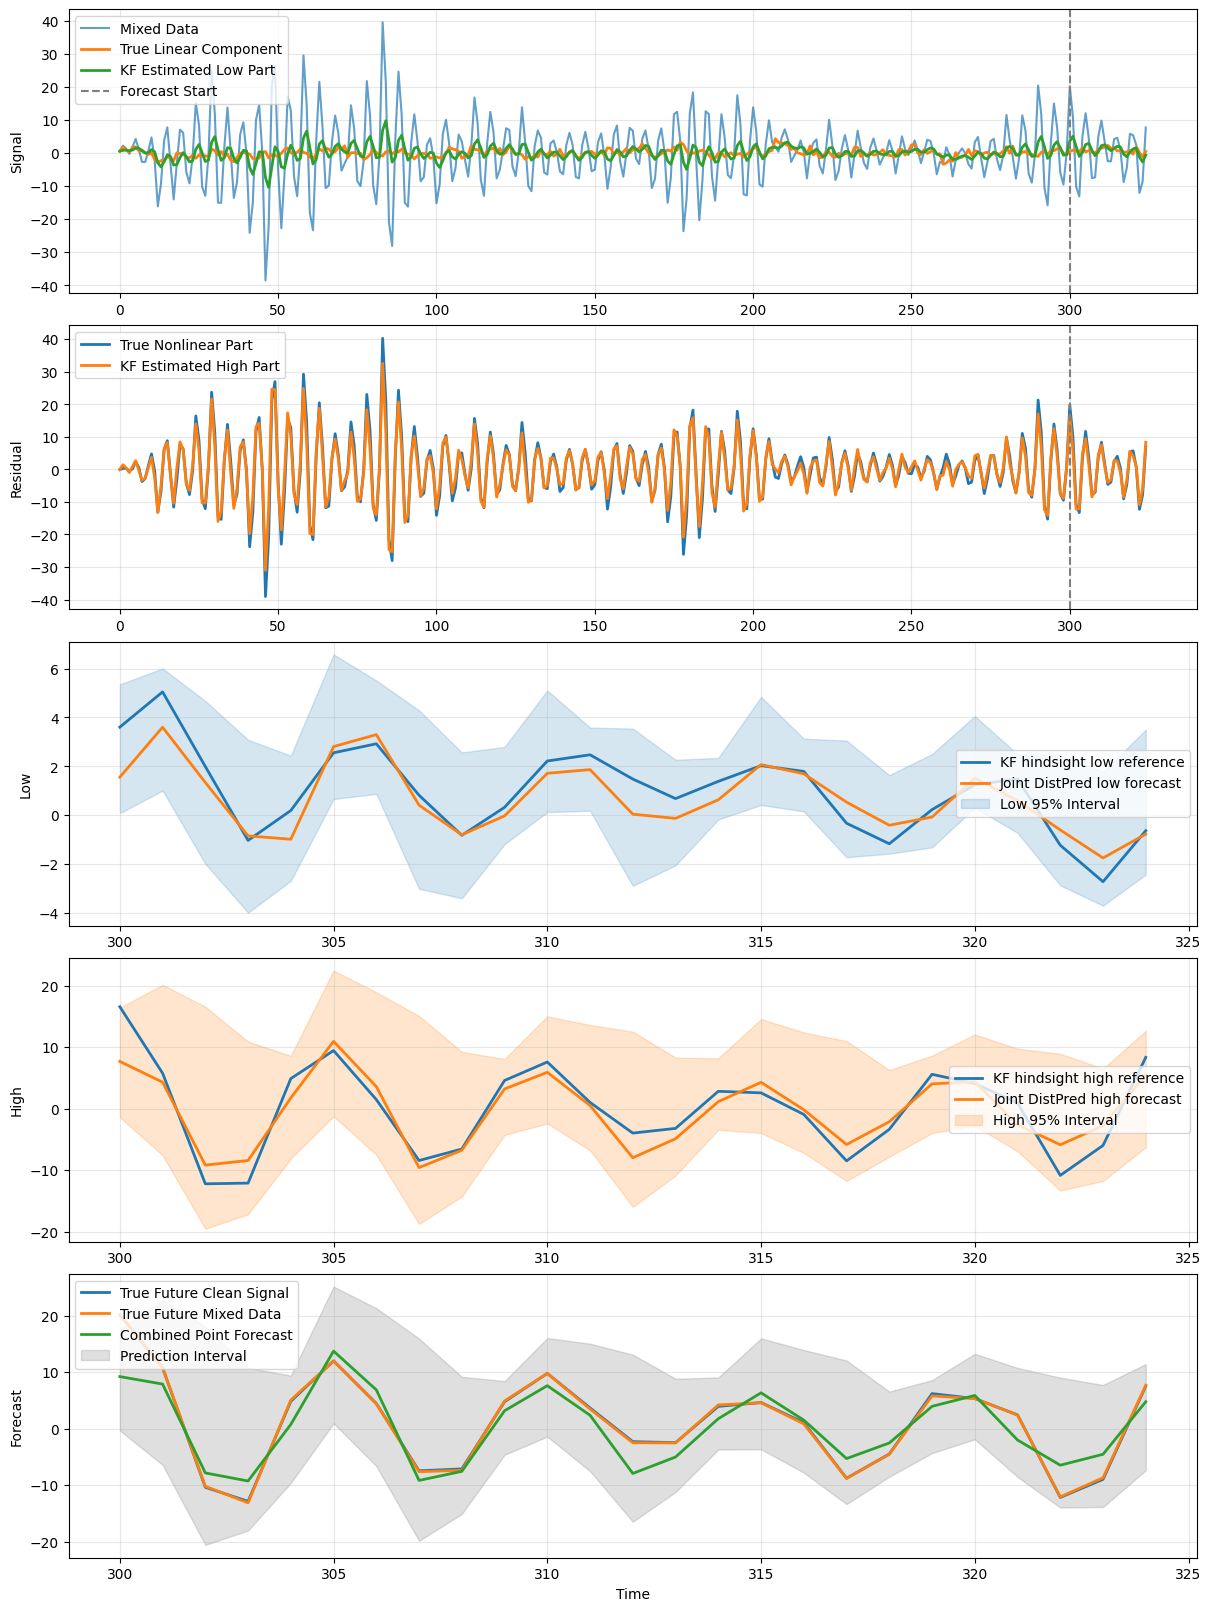

In [9]:
from pathlib import Path
from IPython.display import Image, display

photo_dir = Path("C:/Users/allen/OneDrive/Desktop/程式/meeting/photo")
photo_dir.mkdir(parents=True, exist_ok=True)

corr_plot_path = photo_dir / "joint_lh_component_corr_notebook_h1.png"
interaction_plot_path = photo_dir / "joint_lh_interaction_notebook_h1.png"
forecast_plot_path = photo_dir / "joint_lh_forecast_notebook_h1.png"

t = np.arange(len(result["measurements"]), dtype=float)
t_test = t[train_size:train_size + horizon]

fig, axes = plt.subplots(5, 1, figsize=(12, 16), constrained_layout=True)

axes[0].plot(t, result["measurements"], label="Mixed Data", alpha=0.7)
axes[0].plot(t, result["true_low_full"], label="True Linear Component", linewidth=2)
axes[0].plot(t, result["estimated_low_full"], label="KF Estimated Low Part", linewidth=2)
axes[0].axvline(t[train_size], color="gray", linestyle="--", label="Forecast Start")
axes[0].set_ylabel("Signal")
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, result["true_high_full"], label="True Nonlinear Part", linewidth=2)
axes[1].plot(t, result["estimated_high_full"], label="KF Estimated High Part", linewidth=2)
axes[1].axvline(t[train_size], color="gray", linestyle="--")
axes[1].set_ylabel("Residual")
axes[1].legend(loc="upper left")
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_test, result["reference_low_test"], label="KF hindsight low reference", linewidth=2)
axes[2].plot(t_test, result["low_forecast"], label="Joint DistPred low forecast", linewidth=2)
axes[2].fill_between(
    t_test,
    result["low_interval_lower"],
    result["low_interval_upper"],
    color="tab:blue",
    alpha=0.18,
    label="Low 95% Interval",
)
axes[2].set_ylabel("Low")
axes[2].legend(loc="center right")
axes[2].grid(True, alpha=0.3)

axes[3].plot(t_test, result["reference_high_test"], label="KF hindsight high reference", linewidth=2)
axes[3].plot(t_test, result["high_forecast"], label="Joint DistPred high forecast", linewidth=2)
axes[3].fill_between(
    t_test,
    result["high_interval_lower"],
    result["high_interval_upper"],
    color="tab:orange",
    alpha=0.20,
    label="High 95% Interval",
)
axes[3].set_ylabel("High")
axes[3].legend(loc="center right")
axes[3].grid(True, alpha=0.3)

axes[4].plot(t_test, result["true_clean_test"], label="True Future Clean Signal", linewidth=2)
axes[4].plot(t_test, result["measurements_test"], label="True Future Mixed Data", linewidth=2)
axes[4].plot(t_test, result["final_forecast"], label="Combined Point Forecast", linewidth=2)
axes[4].fill_between(
    t_test,
    result["interval_lower"],
    result["interval_upper"],
    color="gray",
    alpha=0.25,
    label="Prediction Interval",
)
axes[4].set_ylabel("Forecast")
axes[4].set_xlabel("Time")
axes[4].legend(loc="upper left")
axes[4].grid(True, alpha=0.3)

plt.show()
plt.close(fig)



## Monte Carlo 摘要實驗

這一段會重複執行多次實驗，彙整 MSE、coverage、interval width，以及 component correlation 的平均表現。

In [10]:
n_monte_carlo = 50
train_size = 300
horizons = [10, 25, 50]
ensemble_size = 50

print("Mode                          : M1+M3 additive data with paper26-style Joint (L,H) DistPred")
print(f"Monte Carlo runs               : {n_monte_carlo}")
print(f"Observed sample size T         : {train_size}")
print(f"Ensemble samples K             : {ensemble_size}")
print("")
print("h | Mean low MSE | Mean high MSE | Mean noisy MSE | Mean noisy RMSE | Mean test std | Mean nRMSE | Mean noisy coverage | Mean interval width")
print("--|--------------|---------------|----------------|-----------------|---------------|------------|---------------------|--------------------")

start_time = time.perf_counter()

for horizon in horizons:
    experiment_results = []
    for run_idx in range(n_monte_carlo):
        np.random.seed(42 + run_idx)
        experiment_results.append(
            run_single_experiment(
                train_size=train_size,
                horizon=horizon,
                ensemble_size=ensemble_size,
            )
        )

    low_mses = np.array([result["low_mse"] for result in experiment_results], dtype=float)
    high_mses = np.array([result["high_mse"] for result in experiment_results], dtype=float)
    noisy_mses = np.array([result["final_noisy_mse"] for result in experiment_results], dtype=float)
    noisy_rmses = np.array([result["final_noisy_rmse"] for result in experiment_results], dtype=float)
    test_stds = np.array([result["test_std"] for result in experiment_results], dtype=float)
    normalized_rmses = np.array([result["normalized_rmse"] for result in experiment_results], dtype=float)
    noisy_coverages = np.array([result["noisy_coverage"] for result in experiment_results], dtype=float)
    low_component_coverages = np.array([result["low_component_coverage"] for result in experiment_results], dtype=float)
    high_component_coverages = np.array([result["high_component_coverage"] for result in experiment_results], dtype=float)
    mean_interval_widths = np.array([result["mean_interval_width"] for result in experiment_results], dtype=float)
    low_sample_widths = np.array([result["low_sample_width"] for result in experiment_results], dtype=float)
    high_sample_widths = np.array([result["high_sample_width"] for result in experiment_results], dtype=float)
    final_sample_widths = np.array([result["final_sample_width"] for result in experiment_results], dtype=float)
    true_component_corrs = np.array(
        [result["true_component_corr"]["pearson_corr"] for result in experiment_results],
        dtype=float,
    )
    kf_component_corrs = np.array(
        [result["kf_component_corr"]["pearson_corr"] for result in experiment_results],
        dtype=float,
    )
    true_component_corrsq = np.array(
        [result["true_component_corr"]["corr_sq"] for result in experiment_results],
        dtype=float,
    )
    kf_component_corrsq = np.array(
        [result["kf_component_corr"]["corr_sq"] for result in experiment_results],
        dtype=float,
    )
    mean_data_generation = np.mean([result["timing_info"]["data_generation"] for result in experiment_results])
    mean_point_forecast_fit = np.mean([result["timing_info"]["point_forecast_fit"] for result in experiment_results])
    mean_kf_decomposition = np.mean([result["timing_info"]["kf_decomposition"] for result in experiment_results])
    mean_joint_distpred_fit_forecast = np.mean(
        [result["timing_info"]["joint_distpred_fit_forecast"] for result in experiment_results]
    )

    print(
        f"{horizon} | "
        f"{np.mean(low_mses):.4f}       | "
        f"{np.mean(high_mses):.4f}        | "
        f"{np.mean(noisy_mses):.4f}         | "
        f"{np.mean(noisy_rmses):.4f}          | "
        f"{np.mean(test_stds):.4f}       | "
        f"{np.mean(normalized_rmses):.4f}     | "
        f"{np.mean(noisy_coverages):.2f}%               | "
        f"{np.mean(mean_interval_widths):.4f}"
    )
    print(
        "    Avg timing (s/run): "
        f"data={mean_data_generation:.2f}, "
        f"point_fit={mean_point_forecast_fit:.2f}"
    )
    print(
        "    Avg model breakdown (s/run): "
        f"kf={mean_kf_decomposition:.2f}, "
        f"joint={mean_joint_distpred_fit_forecast:.2f}"
    )
    print(
        "    Avg component interval: "
        f"low_cov={np.mean(low_component_coverages):.2f}%, "
        f"low_width={np.mean(low_sample_widths):.4f}, "
        f"high_cov={np.mean(high_component_coverages):.2f}%, "
        f"high_width={np.mean(high_sample_widths):.4f}, "
        f"final_width={np.mean(final_sample_widths):.4f}"
    )
    print(
        "    Avg component corr: "
        f"generated={np.mean(true_component_corrs):.4f} (R^2={np.mean(true_component_corrsq):.4f}), "
        f"KF={np.mean(kf_component_corrs):.4f} (R^2={np.mean(kf_component_corrsq):.4f})"
    )

    representative = experiment_results[0]
    photo_dir = Path("C:/Users/allen/OneDrive/Desktop/程式/meeting/photo/m1m3")
    photo_dir.mkdir(parents=True, exist_ok=True)

    interaction_plot_path = photo_dir / f"joint_lh_interaction_h{horizon}.png"
    save_interaction_plot(
        representative["joint_bundle"],
        representative["estimated_low_train"],
        representative["estimated_high_train"],
        interaction_plot_path,
    )
    print(f"    Saved interaction plot     : {interaction_plot_path}")

    corr_plot_path = photo_dir / f"joint_lh_component_corr_h{horizon}.png"
    save_component_correlation_plot(
        representative["true_low_full"],
        representative["true_high_full"],
        representative["estimated_low_full"],
        representative["estimated_high_full"],
        corr_plot_path,
    )
    print(f"    Saved component corr plot  : {corr_plot_path}")

    forecast_plot_path = photo_dir / f"joint_lh_forecast_h{horizon}.png"
    t = np.arange(len(representative["measurements"]), dtype=float)
    t_test = t[train_size:train_size + horizon]
    fig, axes = plt.subplots(5, 1, figsize=(12, 16), constrained_layout=True)

    axes[0].plot(t, representative["measurements"], label="Mixed Data", alpha=0.7)
    axes[0].plot(t, representative["true_low_full"], label="True Linear Component", linewidth=2)
    axes[0].plot(t, representative["estimated_low_full"], label="KF Estimated Low Part", linewidth=2)
    axes[0].axvline(t[train_size], color="gray", linestyle="--", label="Forecast Start")
    axes[0].set_ylabel("Signal")
    axes[0].legend(loc="upper left")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(t, representative["true_high_full"], label="True Nonlinear Part", linewidth=2)
    axes[1].plot(t, representative["estimated_high_full"], label="KF Estimated High Part", linewidth=2)
    axes[1].axvline(t[train_size], color="gray", linestyle="--")
    axes[1].set_ylabel("Residual")
    axes[1].legend(loc="upper left")
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(t_test, representative["reference_low_test"], label="KF hindsight low reference", linewidth=2)
    axes[2].plot(t_test, representative["low_forecast"], label="Joint DistPred low forecast", linewidth=2)
    axes[2].fill_between(
        t_test,
        representative["low_interval_lower"],
        representative["low_interval_upper"],
        color="tab:blue",
        alpha=0.18,
        label="Low 95% Interval",
    )
    axes[2].set_ylabel("Low")
    axes[2].legend(loc="center right")
    axes[2].grid(True, alpha=0.3)

    axes[3].plot(t_test, representative["reference_high_test"], label="KF hindsight high reference", linewidth=2)
    axes[3].plot(t_test, representative["high_forecast"], label="Joint DistPred high forecast", linewidth=2)
    axes[3].fill_between(
        t_test,
        representative["high_interval_lower"],
        representative["high_interval_upper"],
        color="tab:orange",
        alpha=0.20,
        label="High 95% Interval",
    )
    axes[3].set_ylabel("High")
    axes[3].legend(loc="center right")
    axes[3].grid(True, alpha=0.3)

    axes[4].plot(t_test, representative["true_clean_test"], label="True Future Clean Signal", linewidth=2)
    axes[4].plot(t_test, representative["measurements_test"], label="True Future Mixed Data", linewidth=2)
    axes[4].plot(t_test, representative["final_forecast"], label="Combined Point Forecast", linewidth=2)
    axes[4].fill_between(
        t_test,
        representative["interval_lower"],
        representative["interval_upper"],
        color="gray",
        alpha=0.25,
        label="Prediction Interval",
    )
    axes[4].set_ylabel("Forecast")
    axes[4].set_xlabel("Time")
    axes[4].legend(loc="upper left")
    axes[4].grid(True, alpha=0.3)

    fig.savefig(forecast_plot_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"    Saved forecast plot        : {forecast_plot_path}")

elapsed_time = time.perf_counter() - start_time
print("")
print(f"Elapsed time                   : {elapsed_time:.2f} seconds")


Mode                          : M1+M3 additive data with paper26-style Joint (L,H) DistPred
Monte Carlo runs               : 50
Observed sample size T         : 300
Ensemble samples K             : 50

h | Mean low MSE | Mean high MSE | Mean noisy MSE | Mean noisy RMSE | Mean test std | Mean nRMSE | Mean noisy coverage | Mean interval width
--|--------------|---------------|----------------|-----------------|---------------|------------|---------------------|--------------------
10 | 0.8763       | 11.5611        | 16.9077         | 3.7810          | 8.9154       | 0.4375     | 91.80%               | 18.2358
    Avg timing (s/run): data=0.00, point_fit=1.43
    Avg model breakdown (s/run): kf=0.00, joint=1.43
    Avg component interval: low_cov=95.80%, low_width=5.0827, high_cov=94.20%, high_width=17.7503, final_width=18.2358
    Avg component corr: generated=0.0834 (R^2=0.0084), KF=0.4773 (R^2=0.2284)
    Saved interaction plot     : C:\Users\allen\OneDrive\Desktop\程式\meeting\photo\m1